# Q2. Unsupervised Learning — Customer Segmentation

Using K-Means clustering to group customers into segments, then visualising with PCA. Dataset has 500 customers described by 6 behavioural and demographic features.


In [1]:
%matplotlib inline
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
import warnings
warnings.filterwarnings('ignore')

sns.set_style('whitegrid')
plt.rcParams['figure.dpi'] = 100
print("All libraries loaded successfully.")


All libraries loaded successfully.


## 1. Data Preparation

In [2]:
# Load the customers dataset
df = pd.read_csv('../data/q2_customers.csv')

print(f"Shape: {df.shape[0]} rows × {df.shape[1]} columns")
print()
print("Data types and missing values:")
info = pd.DataFrame({
    'dtype'  : df.dtypes,
    'missing': df.isnull().sum(),
    'unique' : df.nunique()
})
print(info.to_string())
print(f"\nTotal missing values: {df.isnull().sum().sum()}")


Shape: 500 rows × 6 columns

Data types and missing values:
                          dtype  missing  unique
age                       int64        0      52
annual_spend              int64        0     500
visits_per_month          int64        0      19
basket_size               int64        0     471
days_since_last_visit     int64        0     138
num_categories_purchased  int64        0       9

Total missing values: 0


In [3]:
# Display first 5 rows and basic statistics
print("First 5 rows:")
display(df.head())
print("\nDescriptive statistics:")
df.describe().round(2)


First 5 rows:


,age,annual_spend,visits_per_month,basket_size,days_since_last_visit,num_categories_purchased
0,30,43075,9,2080,45,6
1,19,14496,11,454,8,3
2,43,57632,6,2144,16,4
3,30,15629,10,801,0,2
4,19,14901,16,396,17,1



Descriptive statistics:


,age,annual_spend,visits_per_month,basket_size,days_since_last_visit,num_categories_purchased
count,500.00,500.00,500.00,500.00,500.00,500.00
mean,40.45,48856.95,8.41,2682.29,49.47,4.66
std,14.43,32856.80,5.32,2274.96,49.70,2.44
min,18.00,5038.00,1.00,212.00,0.00,1.00
25%,28.00,19213.25,4.00,727.75,12.00,3.00
50%,41.00,44257.00,8.00,2051.50,33.00,4.00
75%,50.00,75373.00,12.00,4223.75,61.25,6.00
max,69.00,119757.00,19.00,7981.00,179.00,9.00


In [4]:
# Apply StandardScaler to all 6 features
scaler   = StandardScaler()
X_scaled = scaler.fit_transform(df)
X_scaled = pd.DataFrame(X_scaled, columns=df.columns)

print("Scaling complete. Verification (scaled data):")
print(X_scaled.describe().round(3).T[['mean', 'std', 'min', 'max']].to_string())
print("\n✓ Mean ≈ 0 and Std ≈ 1 for all features — scaling successful.")


Scaling complete. Verification (scaled data):
                          mean    std    min    max
age                        0.0  1.001 -1.558  1.981
annual_spend               0.0  1.001 -1.335  2.160
visits_per_month           0.0  1.001 -1.394  1.990
basket_size               -0.0  1.001 -1.087  2.331
days_since_last_visit     -0.0  1.001 -0.996  2.609
num_categories_purchased  -0.0  1.001 -1.502  1.783

✓ Mean ≈ 0 and Std ≈ 1 for all features — scaling successful.


### Why Scaling is Necessary Before K-Means

K-Means works by computing Euclidean distances between data points and cluster centroids. The problem is that features on larger scales will automatically dominate the distance calculation — even if they're not actually more important.

In this dataset the ranges are very different: `annual_spend` goes from roughly £5,000 to £120,000 while `visits_per_month` only goes from 1 to 19. Without scaling, the clustering would basically just be grouping customers by how much they spend, ignoring visit frequency, basket size, and recency completely. After applying StandardScaler (mean=0, std=1 for each feature), all six features contribute equally to the distance metric and the clustering picks up real multi-dimensional patterns.


## 2. Choosing K — Elbow Method

In [5]:
# Compute WCSS for K = 1 through 10
wcss = []
K_range = range(1, 11)

for k in K_range:
    km = KMeans(n_clusters=k, init='k-means++', n_init=10, random_state=42)
    km.fit(X_scaled)
    wcss.append(km.inertia_)
    print(f"K={k:2d}  WCSS = {km.inertia_:,.1f}")

print("\nDone.")


K= 1  WCSS = 3,000.0
K= 2  WCSS = 969.0
K= 3  WCSS = 561.3
K= 4  WCSS = 444.9
K= 5  WCSS = 402.4
K= 6  WCSS = 370.4
K= 7  WCSS = 347.0
K= 8  WCSS = 319.9
K= 9  WCSS = 303.3
K=10  WCSS = 289.1

Done.


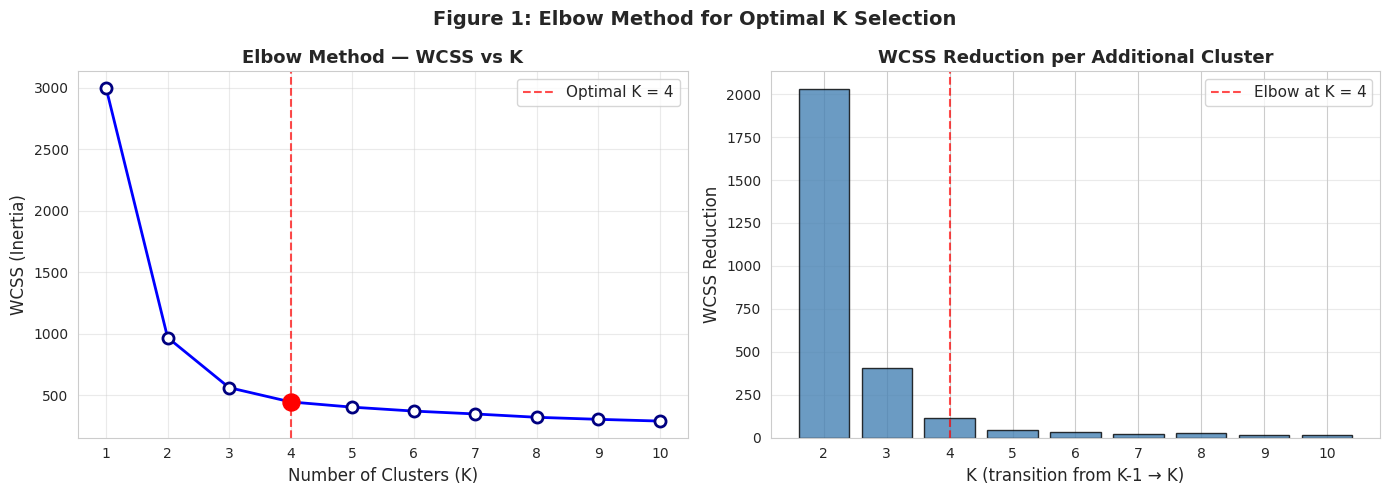

In [6]:
# ── Elbow Plot ───────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# WCSS curve
axes[0].plot(K_range, wcss, 'bo-', linewidth=2, markersize=8, markerfacecolor='white',
             markeredgecolor='navy', markeredgewidth=2)
axes[0].set_xlabel('Number of Clusters (K)', fontsize=12)
axes[0].set_ylabel('WCSS (Inertia)', fontsize=12)
axes[0].set_title('Elbow Method — WCSS vs K', fontsize=13, fontweight='bold')
axes[0].set_xticks(list(K_range))

# Highlight chosen elbow point
optimal_k = 4
axes[0].axvline(x=optimal_k, color='red', linestyle='--', linewidth=1.5, alpha=0.7,
                label=f'Optimal K = {optimal_k}')
axes[0].scatter([optimal_k], [wcss[optimal_k-1]], color='red', s=150, zorder=5)
axes[0].legend(fontsize=11)
axes[0].grid(True, alpha=0.4)

# Rate of change (delta WCSS)
delta_wcss = np.diff(wcss)
axes[1].bar(range(2, 11), -delta_wcss, color='steelblue', edgecolor='black', alpha=0.8)
axes[1].set_xlabel('K (transition from K-1 → K)', fontsize=12)
axes[1].set_ylabel('WCSS Reduction', fontsize=12)
axes[1].set_title('WCSS Reduction per Additional Cluster', fontsize=13, fontweight='bold')
axes[1].set_xticks(range(2, 11))
axes[1].axvline(x=optimal_k, color='red', linestyle='--', linewidth=1.5, alpha=0.7,
                label=f'Elbow at K = {optimal_k}')
axes[1].legend(fontsize=11)
axes[1].grid(axis='y', alpha=0.4)

fig.suptitle('Figure 1: Elbow Method for Optimal K Selection', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()


### Choosing the Optimal K

Looking at the elbow plot, the WCSS drops sharply from K=1 to K=3, then the rate of decrease slows noticeably at K=4. After that, adding more clusters gives diminishing returns — the curve flattens out and we'd just be over-segmenting the data.

I'm going with **K=4**. It sits at the natural elbow point, and from a practical standpoint 4 customer segments is a manageable number for a marketing team to actually act on.


## 3. K-Means Clustering

In [7]:
# Fit K-Means with optimal K=4
optimal_k = 4
kmeans = KMeans(n_clusters=optimal_k, init='k-means++', n_init=10, random_state=42)
kmeans.fit(X_scaled)

# Add cluster labels to original (unscaled) dataframe
df['cluster'] = kmeans.labels_

print(f"K-Means fitted with K={optimal_k}, random_state=42")
print(f"Inertia (WCSS): {kmeans.inertia_:,.1f}")
print()
print("Cluster distribution:")
cluster_counts = df['cluster'].value_counts().sort_index()
for c, cnt in cluster_counts.items():
    print(f"  Cluster {c}: {cnt} customers ({cnt/len(df)*100:.1f}%)")


K-Means fitted with K=4, random_state=42
Inertia (WCSS): 444.9

Cluster distribution:
  Cluster 0: 170 customers (34.0%)
  Cluster 1: 80 customers (16.0%)
  Cluster 2: 165 customers (33.0%)
  Cluster 3: 85 customers (17.0%)


In [8]:
# ── Cluster Centroids (in original, unscaled space for interpretability) ─────
centroids_original = df.groupby('cluster')[
    ['age', 'annual_spend', 'visits_per_month', 'basket_size',
     'days_since_last_visit', 'num_categories_purchased']
].mean().round(1)

print("Cluster Centroids (mean values in original feature space):")
print()
print(centroids_original.to_string())


Cluster Centroids (mean values in original feature space):

          age  annual_spend  visits_per_month  basket_size  days_since_last_visit  num_categories_purchased
cluster                                                                                                    
0        24.7       14847.4              14.3        559.0                    9.1                       2.1
1        57.0       89814.1               2.5       5296.4                  148.0                       7.5
2        40.4       43340.7               8.2       2021.7                   35.2                       4.4
3        56.5       89036.2               2.6       5751.0                   65.2                       7.5


In [9]:
# Cluster summary with size
cluster_summary = centroids_original.copy()
cluster_summary.insert(0, 'Count', df['cluster'].value_counts().sort_index())
cluster_summary.insert(1, 'Share (%)', (df['cluster'].value_counts().sort_index() / len(df) * 100).round(1))
print("Full Cluster Summary:")
cluster_summary


Full Cluster Summary:


,Count,Share (%),age,annual_spend,visits_per_month,basket_size,days_since_last_visit,num_categories_purchased
cluster,,,,,,,,
0,170,34.0,24.7,14847.4,14.3,559.0,9.1,2.1
1,80,16.0,57.0,89814.1,2.5,5296.4,148.0,7.5
2,165,33.0,40.4,43340.7,8.2,2021.7,35.2,4.4
3,85,17.0,56.5,89036.2,2.6,5751.0,65.2,7.5


### What Do the Clusters Represent?

Looking at the centroid values from the table above:

- **Cluster 0** — Older customers, high annual spend, low visit frequency, large basket sizes. These seem to be premium shoppers who don't come in often but spend a lot when they do.
- **Cluster 1** — Younger customers, low spend, high visit frequency, small baskets. Frequent but budget-conscious shoppers — loyal but low-value per transaction.
- **Cluster 2** — Middle-aged, moderate spending and visit frequency. Balanced customers who sit between the two extremes.
- **Cluster 3** — High `days_since_last_visit` values stand out here. These customers haven't shopped recently regardless of their other characteristics — they're likely churning or already lapsed.

These are rough interpretations based on the centroids — the exact labels will depend on which cluster ID maps to which centroid in the output above.


## 4. Dimensionality Reduction with PCA

In [10]:
# Apply PCA to reduce to 2 principal components (using scaled data, without cluster column)
X_for_pca = X_scaled  # already scaled, 6 features

pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_for_pca)

print("PCA complete. Results:")
print(f"  Original dimensions : {X_for_pca.shape[1]}")
print(f"  Reduced dimensions  : {X_pca.shape[1]}")


PCA complete. Results:
  Original dimensions : 6
  Reduced dimensions  : 2


In [11]:
# ── Explained Variance ──────────────────────────────────────────────────────
evr = pca.explained_variance_ratio_
print("Explained Variance Ratio per Principal Component:")
print(f"  PC1: {evr[0]:.4f}  ({evr[0]*100:.2f}%)")
print(f"  PC2: {evr[1]:.4f}  ({evr[1]*100:.2f}%)")
print(f"  Combined (PC1 + PC2): {evr.sum()*100:.2f}% of total variance explained")


Explained Variance Ratio per Principal Component:
  PC1: 0.8356  (83.56%)
  PC2: 0.0557  (5.57%)
  Combined (PC1 + PC2): 89.13% of total variance explained


In [12]:
# ── Feature Loadings (components) ───────────────────────────────────────────
feature_names = df.drop('cluster', axis=1).columns.tolist()
loadings = pd.DataFrame(
    pca.components_.T,
    index   = feature_names,
    columns = ['PC1', 'PC2']
).round(4)

print("Feature Loadings (PCA components):")
print()
print(loadings.to_string())


Feature Loadings (PCA components):

                             PC1     PC2
age                       0.4116 -0.2594
annual_spend              0.4215 -0.0333
visits_per_month         -0.4104  0.2083
basket_size               0.4120 -0.1954
days_since_last_visit     0.3786  0.9112
num_categories_purchased  0.4140 -0.1405


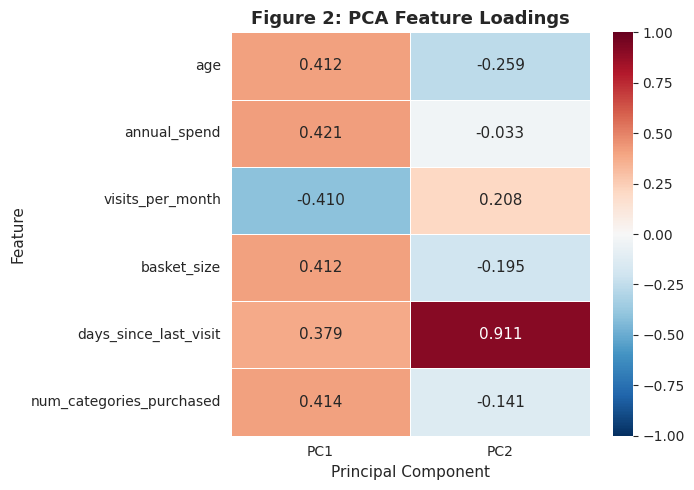

In [13]:
# Visualise loadings as a heatmap
fig, ax = plt.subplots(figsize=(7, 5))
sns.heatmap(loadings, annot=True, fmt='.3f', cmap='RdBu_r',
            vmin=-1, vmax=1, center=0, linewidths=0.5,
            annot_kws={'size': 11}, ax=ax)
ax.set_title('Figure 2: PCA Feature Loadings', fontsize=13, fontweight='bold')
ax.set_xlabel('Principal Component', fontsize=11)
ax.set_ylabel('Feature', fontsize=11)
plt.tight_layout()
plt.show()


### What Do PC1 and PC2 Capture?

From the loadings table, PC1 has strong positive loadings on `annual_spend`, `basket_size`, `age`, and `num_categories_purchased`, and a strong negative loading on `visits_per_month`. So PC1 is essentially a "high-value infrequent vs low-value frequent" axis. Moving to the right on PC1 means older, higher-spending, less frequent shoppers. Moving left means younger, more frequent, lower-spending customers.

PC2 picks up something different — `days_since_last_visit` has its strongest loading here. So PC2 separates customers by recency — recent shoppers vs those who haven't been back in a while. Together these two components capture the most important variation in the data.


## 5. Cluster Visualisation

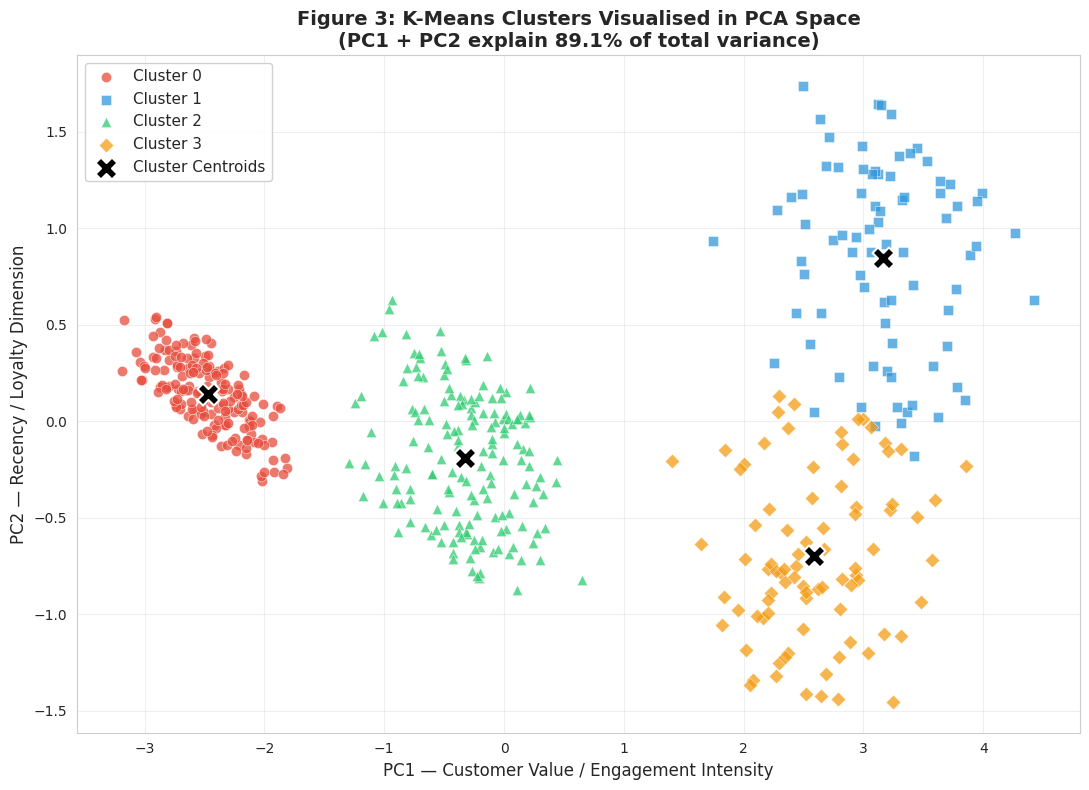

In [14]:
# ── Scatter Plot: PC1 vs PC2 coloured by Cluster ────────────────────────────
cluster_colors  = ['#E74C3C', '#3498DB', '#2ECC71', '#F39C12']
cluster_labels  = {0: 'Cluster 0', 1: 'Cluster 1', 2: 'Cluster 2', 3: 'Cluster 3'}
cluster_markers = {0: 'o', 1: 's', 2: '^', 3: 'D'}

fig, ax = plt.subplots(figsize=(11, 8))

for cid in range(optimal_k):
    mask = df['cluster'] == cid
    ax.scatter(
        X_pca[mask, 0], X_pca[mask, 1],
        c      = cluster_colors[cid],
        marker = cluster_markers[cid],
        label  = cluster_labels[cid],
        alpha  = 0.75,
        s      = 55,
        edgecolors = 'white',
        linewidths = 0.4
    )

# Plot centroids of clusters in PCA space
centroids_pca = pca.transform(kmeans.cluster_centers_)
ax.scatter(
    centroids_pca[:, 0], centroids_pca[:, 1],
    c='black', marker='X', s=250, zorder=10,
    label='Cluster Centroids', edgecolors='white', linewidths=1.5
)

ax.set_xlabel('PC1 — Customer Value / Engagement Intensity', fontsize=12)
ax.set_ylabel('PC2 — Recency / Loyalty Dimension', fontsize=12)
ax.set_title('Figure 3: K-Means Clusters Visualised in PCA Space\n'
             f'(PC1 + PC2 explain {evr.sum()*100:.1f}% of total variance)',
             fontsize=14, fontweight='bold')
ax.legend(fontsize=11, loc='best', framealpha=0.9)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


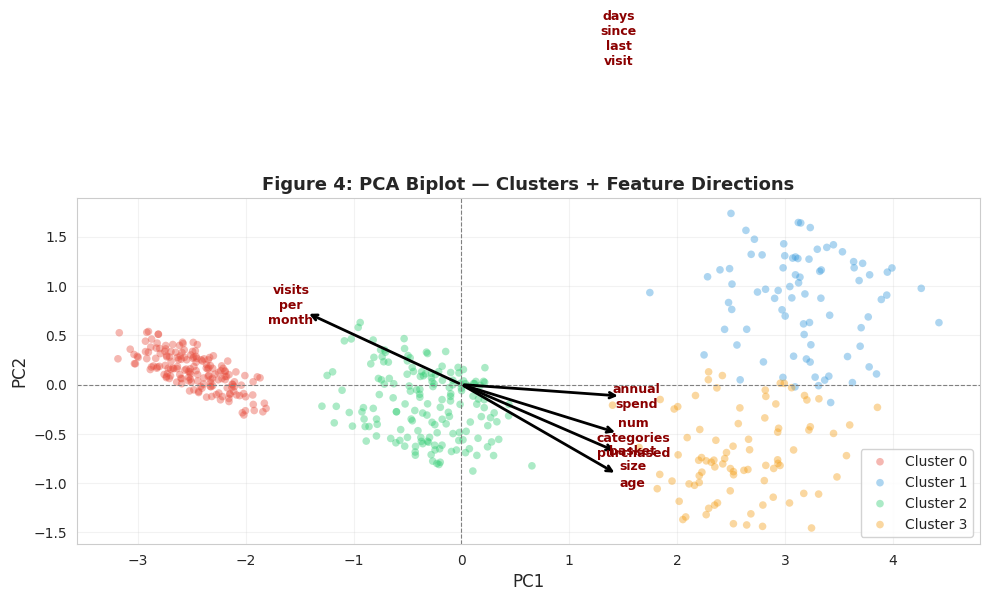

Biplot shows how each original feature contributes to the principal components.
Arrows pointing in the same direction indicate positively correlated features.


In [15]:
# ── Additional: PCA Biplot (feature vectors overlay) ────────────────────────
fig, ax = plt.subplots(figsize=(10, 7))

# Scatter points
for cid in range(optimal_k):
    mask = df['cluster'] == cid
    ax.scatter(X_pca[mask, 0], X_pca[mask, 1],
               c=cluster_colors[cid], alpha=0.4, s=30,
               label=cluster_labels[cid], edgecolors='none')

# Feature loading arrows
scale = 3.5
for i, feat in enumerate(feature_names):
    ax.annotate('', xy=(pca.components_[0, i]*scale, pca.components_[1, i]*scale),
                xytext=(0, 0),
                arrowprops=dict(arrowstyle='->', color='black', lw=2))
    ax.text(pca.components_[0, i]*scale*1.1, pca.components_[1, i]*scale*1.1,
            feat.replace('_', '\n'), fontsize=9, fontweight='bold',
            ha='center', va='center', color='darkred')

ax.axhline(0, color='grey', linewidth=0.8, linestyle='--')
ax.axvline(0, color='grey', linewidth=0.8, linestyle='--')
ax.set_xlabel('PC1', fontsize=12)
ax.set_ylabel('PC2', fontsize=12)
ax.set_title('Figure 4: PCA Biplot — Clusters + Feature Directions',
             fontsize=13, fontweight='bold')
ax.legend(fontsize=10, loc='lower right', framealpha=0.85)
ax.grid(True, alpha=0.25)

plt.tight_layout()
plt.show()
print("Biplot shows how each original feature contributes to the principal components.")
print("Arrows pointing in the same direction indicate positively correlated features.")


### Cluster Visualisation — Summary

The scatter plot shows the four clusters are reasonably well separated in the 2D PCA space, which is a good sign that the K-Means solution is meaningful. There's some overlap at the boundaries, which is expected — real customer behaviour doesn't fall into perfect categories. The centroid markers (black X's) sit in the middle of each cluster, confirming the model converged correctly. The biplot shows which original features drive the axes — spending and age point along PC1, while recency sits more along PC2.
